# 📊 Preparing Features for Machine Learning in Finance
### *Normalization, Scaling, and Standardization*

---

**Level:** Beginner to Intermediate  
**Prerequisites:** Basic Python, familiarity with NumPy and Pandas

---

## 🗺️ What We'll Cover

| Section | Topic | Time |
|---|---|---|
| 1 | Why Normalization Matters in Finance 
| 2 | Min–Max Scaling 
| 3 | Z-Score Standardization 
| 4 | Robust Scaling
| 5 | Side-by-Side Comparison & When to Use What 

---

> **💡 Core Idea:** Raw financial data is messy. Stock prices are in the hundreds, trading volumes in the millions, and portfolio weights between 0 and 1 — all in the same model. Without scaling, your ML model will think "volume" is more important than "return" just because the numbers are bigger. Scaling fixes that.

## ⚙️ Setup — Run This First

We'll use a few standard libraries. Everything here comes pre-installed in most Python environments.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Make our charts look clean
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Fix random seed so everyone gets the same results
np.random.seed(42)

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


---
## Section 1 — Why Normalization Matters in Finance ⏱️

### The Problem: Features Live on Wildly Different Scales

Imagine building a model to predict credit risk using these features:

| Feature | Typical Range | Example Value |
|---|---|---|
| Annual Income | ₹200,000 – ₹5,000,000 | ₹800,000 |
| Credit Score | 300 – 850 | 720 |
| Debt-to-Income Ratio | 0.05 – 0.90 | 0.35 |
| Number of Accounts | 1 – 30 | 7 |

Without scaling, a model like linear regression or a neural network will **unintentionally give more weight to income** simply because its numbers are larger — not because it's actually more predictive.

### The Solution: Bring Everything to a Common Scale

We have three main tools:
- **Min-Max Scaling** → squish everything into [0, 1]
- **Z-Score Standardization** → center at 0, spread at 1
- **Robust Scaling** → like Z-score, but ignores outliers

Let's build a realistic dataset to explore all three.

In [2]:
# -------------------------------------------------------
# Simulating a realistic financial dataset
# 500 loan applicants with 4 features
# -------------------------------------------------------

n = 500

df = pd.DataFrame({
    # Annual income: roughly log-normal (most people cluster around middle)
    'annual_income': np.random.lognormal(mean=13.5, sigma=0.6, size=n),

    # Credit score: roughly normal, capped between 300-850
    'credit_score': np.clip(np.random.normal(loc=680, scale=80, size=n), 300, 850),

    # Debt-to-income ratio: between 0 and 1
    'debt_to_income': np.clip(np.random.beta(a=2, b=5, size=n), 0.01, 0.99),

    # Transaction amount: highly skewed — most are small, a few are huge
    # We add a few extreme outliers intentionally to demonstrate Robust Scaling
    'transaction_amount': np.concatenate([
        np.random.exponential(scale=5000, size=n - 10),
        np.random.uniform(200000, 500000, size=10)  # 10 big outliers
    ])
})

print("Dataset shape:", df.shape)
print("\n📋 First 5 rows:")
df.head()

Dataset shape: (500, 4)

📋 First 5 rows:


,annual_income,credit_score,debt_to_income,transaction_amount
0,9.826699e+05,754.094204,0.376510,6767.034686
1,6.713470e+05,832.753331,0.338881,3391.973387
2,1.075841e+06,568.114594,0.334857,3300.311490
3,1.819037e+06,725.037539,0.439946,9107.911543
4,6.338122e+05,627.948594,0.497788,2242.414582


In [3]:
# See the scale problem clearly
# Notice how different the min/max values are across features!

print("📊 Summary Statistics — Notice the wildly different scales:\n")
df.describe().round(2)

📊 Summary Statistics — Notice the wildly different scales:



,annual_income,credit_score,debt_to_income,transaction_amount
count,500.00,500.00,500.00,500.00
mean,877449.37,682.10,0.29,12168.75
std,626210.77,77.18,0.16,51954.39
min,104322.21,464.25,0.01,3.27
25%,479172.41,632.38,0.17,1371.76
50%,735038.60,682.28,0.26,3235.84
75%,1068829.18,732.10,0.40,7202.26
max,7360503.47,850.00,0.78,454066.17


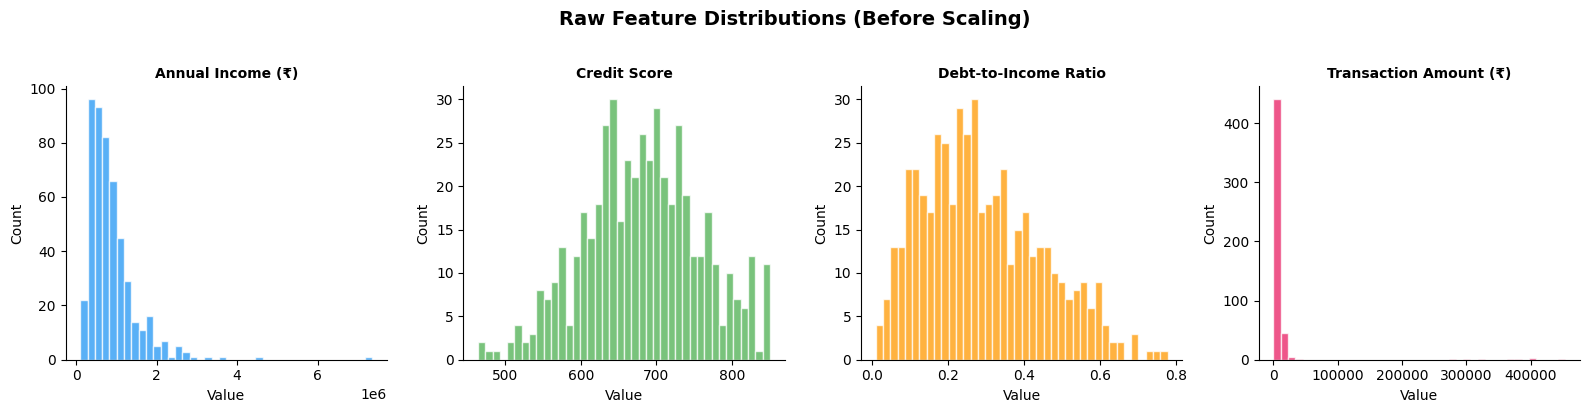


🔍 Observations:
  • annual_income  → right-skewed (log-normal). Most people earn moderate amounts.
  • credit_score   → roughly bell-shaped (normal). Nice symmetric distribution.
  • debt_to_income → slightly right-skewed. Most people have manageable debt.
  • transaction_amount → heavily right-skewed with extreme outliers on the far right.



In [4]:
# Visualize the raw distributions
# This helps us understand the shape of each feature
# before we decide which scaler to apply

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Raw Feature Distributions (Before Scaling)', fontsize=14, fontweight='bold', y=1.02)

features = ['annual_income', 'credit_score', 'debt_to_income', 'transaction_amount']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
labels = ['Annual Income (₹)', 'Credit Score', 'Debt-to-Income Ratio', 'Transaction Amount (₹)']

for ax, feat, color, label in zip(axes, features, colors, labels):
    ax.hist(df[feat], bins=40, color=color, alpha=0.75, edgecolor='white')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

print("""
🔍 Observations:
  • annual_income  → right-skewed (log-normal). Most people earn moderate amounts.
  • credit_score   → roughly bell-shaped (normal). Nice symmetric distribution.
  • debt_to_income → slightly right-skewed. Most people have manageable debt.
  • transaction_amount → heavily right-skewed with extreme outliers on the far right.
""")

---
## Section 2 — Min–Max Scaling ⏱️

### The Formula

$$X_{\text{scaled}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}$$

This maps **every value to the range [0, 1]**.
- The smallest value in the column becomes **0**
- The largest value becomes **1**
- Everything else is proportionally in between

### ✅ When to Use Min-Max
- **Neural networks** — activation functions like sigmoid work well in [0, 1]
- **Image-like financial data** — heatmaps, correlation matrices
- **When you know the true min/max** — e.g., percentage features already bounded

### ⚠️ Watch Out For
- **Outliers destroy it.** One extreme value compresses everything else into a tiny range.
- If a new data point falls *outside* the training min/max, the scaled value goes outside [0, 1].

> 📌 **Finance Example:** If one trader's transaction is ₹5,000,000 and everyone else trades under ₹50,000, Min-Max will push all the normal transactions near zero and that outlier becomes 1.0.

In [5]:
# Let's first implement Min-Max by hand
# to understand exactly what's happening under the hood

# Pick credit score — it's the cleanest feature to start with
credit = df['credit_score'].values

# Manual Min-Max formula
x_min = credit.min()
x_max = credit.max()
credit_minmax_manual = (credit - x_min) / (x_max - x_min)

print(f"Original Credit Score → Min: {x_min:.1f}, Max: {x_max:.1f}")
print(f"After Min-Max        → Min: {credit_minmax_manual.min():.4f}, Max: {credit_minmax_manual.max():.4f}")
print(f"\n✅ Confirmed: values now live in [0, 1]")

Original Credit Score → Min: 464.2, Max: 850.0
After Min-Max        → Min: 0.0000, Max: 1.0000

✅ Confirmed: values now live in [0, 1]


In [6]:
# Now let's use scikit-learn's MinMaxScaler
# This is the production way — handles edge cases properly

scaler_minmax = MinMaxScaler()

# fit_transform learns the min/max AND applies the transformation
# In production: fit on TRAINING data, then transform test data separately
df_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(df),
    columns=df.columns
)

print("After Min-Max Scaling:")
df_minmax.describe().round(4)

After Min-Max Scaling:


,annual_income,credit_score,debt_to_income,transaction_amount
count,500.0000,500.0000,500.0000,500.0000
mean,0.1065,0.5647,0.3635,0.0268
std,0.0863,0.2001,0.2039,0.1144
min,0.0000,0.0000,0.0000,0.0000
25%,0.0517,0.4358,0.2076,0.0030
50%,0.0869,0.5652,0.3312,0.0071
75%,0.1329,0.6944,0.5020,0.0159
max,1.0000,1.0000,1.0000,1.0000


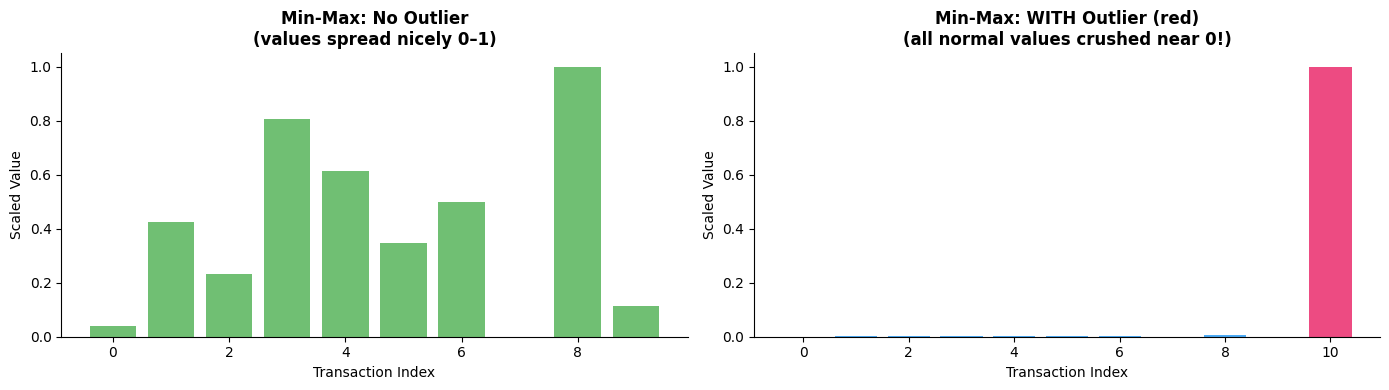


⚠️  With the outlier present, all normal transactions scale to near 0.
   The outlier 'steals' the scale, making normal variation invisible to the model.


In [7]:
# DEMONSTRATION: How outliers break Min-Max
# This is the most important thing to understand about Min-Max!

# Create a simple example: normal transactions + 1 huge outlier
normal_transactions = np.array([1000, 2000, 1500, 3000, 2500, 1800, 2200, 900, 3500, 1200])
with_outlier = np.append(normal_transactions, 500000)  # One huge trade

# Scale both
scaler = MinMaxScaler()
scaled_normal = scaler.fit_transform(normal_transactions.reshape(-1, 1)).flatten()
scaled_with_outlier = MinMaxScaler().fit_transform(with_outlier.reshape(-1, 1)).flatten()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Without outlier
ax1.bar(range(len(normal_transactions)), scaled_normal, color='#4CAF50', alpha=0.8)
ax1.set_title('Min-Max: No Outlier\n(values spread nicely 0–1)', fontweight='bold')
ax1.set_ylabel('Scaled Value')
ax1.set_xlabel('Transaction Index')
ax1.set_ylim(0, 1.05)

# With outlier
colors_bar = ['#E91E63' if i == len(with_outlier) - 1 else '#2196F3' for i in range(len(with_outlier))]
ax2.bar(range(len(with_outlier)), scaled_with_outlier[:-1].tolist() + [scaled_with_outlier[-1]], color=colors_bar, alpha=0.8)
ax2.set_title('Min-Max: WITH Outlier (red)\n(all normal values crushed near 0!)', fontweight='bold')
ax2.set_ylabel('Scaled Value')
ax2.set_xlabel('Transaction Index')
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print("\n⚠️  With the outlier present, all normal transactions scale to near 0.")
print("   The outlier 'steals' the scale, making normal variation invisible to the model.")

---
## Section 3 — Z-Score Standardization ⏱️

### The Formula

$$X_{\text{scaled}} = \frac{X - \mu}{\sigma}$$

Where $\mu$ is the **mean** and $\sigma$ is the **standard deviation**.

This transforms data so that:
- **Mean = 0** (the distribution is centered at zero)
- **Standard Deviation = 1** (the spread is standardized)
- Values are now measured in "how many standard deviations from the mean"

### ✅ When to Use Z-Score
- **Normally distributed features** — returns, credit scores, risk metrics
- **Linear models** (regression, SVM, PCA) — these assume zero-centered data
- **When outliers aren't extreme** — Z-score is affected by outliers, but less than Min-Max
- **When you want to compare across different financial series** — e.g., cross-sectional ranking

### ⚠️ Watch Out For
- **Assumes approximate normality** — applying it to heavily skewed data (like transaction amounts) can mislead the model
- Still sensitive to extreme outliers, just less catastrophically so

> 📌 **Finance Example:** Daily stock returns are often roughly normally distributed. Z-scoring them makes it easy to flag days that are "2 standard deviations away" — a classic risk signal.

In [8]:
# -------------------------------------------------------
# Implement Z-Score by hand first
# -------------------------------------------------------

credit = df['credit_score'].values

mu = credit.mean()
sigma = credit.std()

credit_zscore_manual = (credit - mu) / sigma

print(f"Original Credit Score → Mean: {mu:.2f}, Std: {sigma:.2f}")
print(f"After Z-Score         → Mean: {credit_zscore_manual.mean():.6f}, Std: {credit_zscore_manual.std():.6f}")
print(f"\n✅ Mean ≈ 0, Std ≈ 1")
print(f"\n💡 A scaled value of 2.0 means the person's credit score is 2 standard deviations ABOVE average.")
print(f"   A scaled value of -1.5 means they're 1.5 standard deviations BELOW average.")

Original Credit Score → Mean: 682.10, Std: 77.10
After Z-Score         → Mean: 0.000000, Std: 1.000000

✅ Mean ≈ 0, Std ≈ 1

💡 A scaled value of 2.0 means the person's credit score is 2 standard deviations ABOVE average.
   A scaled value of -1.5 means they're 1.5 standard deviations BELOW average.


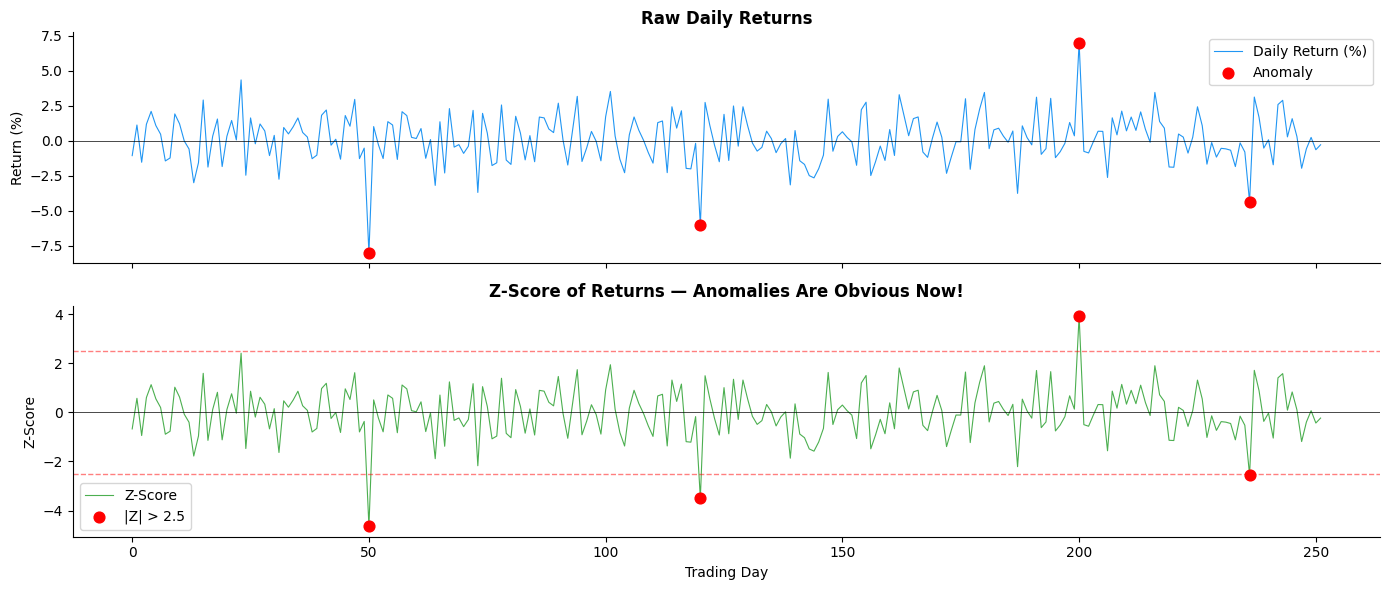


🚨 Anomaly days detected (|Z| > 2.5): [50, 120, 200, 236]
   These match our injected crash and spike days!


In [9]:
# Practical finance use: detecting abnormal return days
# This is how quant analysts use Z-scores every day

# Simulate 252 trading days of daily returns (roughly 1 year)
daily_returns = np.random.normal(loc=0.0005, scale=0.015, size=252)  # mean 0.05%, std 1.5%

# Add a few "crash" days
daily_returns[50] = -0.08   # -8% crash
daily_returns[120] = -0.06  # -6% crash
daily_returns[200] = 0.07   # +7% spike

# Z-score the returns
z_returns = (daily_returns - daily_returns.mean()) / daily_returns.std()

# Identify anomalies: |z| > 2.5 is unusual
threshold = 2.5
anomaly_days = np.where(np.abs(z_returns) > threshold)[0]

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(daily_returns * 100, color='#2196F3', linewidth=0.8, label='Daily Return (%)')
ax1.scatter(anomaly_days, daily_returns[anomaly_days] * 100, color='red', zorder=5, s=60, label='Anomaly')
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_title('Raw Daily Returns', fontweight='bold')
ax1.set_ylabel('Return (%)')
ax1.legend()

ax2.plot(z_returns, color='#4CAF50', linewidth=0.8, label='Z-Score')
ax2.scatter(anomaly_days, z_returns[anomaly_days], color='red', zorder=5, s=60, label=f'|Z| > {threshold}')
ax2.axhline(threshold, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax2.axhline(-threshold, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_title('Z-Score of Returns — Anomalies Are Obvious Now!', fontweight='bold')
ax2.set_ylabel('Z-Score')
ax2.set_xlabel('Trading Day')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n🚨 Anomaly days detected (|Z| > {threshold}): {anomaly_days.tolist()}")
print("   These match our injected crash and spike days!")

In [10]:
# Z-Score with sklearn on our full dataset

scaler_std = StandardScaler()
df_zscore = pd.DataFrame(
    scaler_std.fit_transform(df),
    columns=df.columns
)

print("After Z-Score Standardization:")
df_zscore.describe().round(4)

# Note: mean ≈ 0, std ≈ 1 for all columns
# But transaction_amount will still show large min/max due to outliers

After Z-Score Standardization:


,annual_income,credit_score,debt_to_income,transaction_amount
count,500.0000,500.0000,500.0000,500.0000
mean,0.0000,0.0000,-0.0000,-0.0000
std,1.0010,1.0010,1.0010,1.0010
min,-1.2358,-2.8254,-1.7844,-0.2344
25%,-0.6366,-0.6449,-0.7654,-0.2080
50%,-0.2276,0.0024,-0.1584,-0.1721
75%,0.3059,0.6485,0.6804,-0.0957
max,10.3632,2.1776,3.1252,8.5140


---
## Section 4 — Robust Scaling ⏱️

### The Problem Z-Score Doesn't Fully Solve

The **mean and standard deviation are sensitive to outliers**. One extreme value shifts the mean and inflates the standard deviation, throwing off Z-score scaling.

### The Solution: Use Median and IQR Instead

$$X_{\text{scaled}} = \frac{X - \text{median}(X)}{\text{IQR}(X)}$$

Where IQR = Q3 − Q1 (the **interquartile range**, the middle 50% of data).

| Statistic | Sensitive to Outliers? |
|---|---|
| Mean | ✅ Yes — one huge value pulls it up |
| Standard Deviation | ✅ Yes — outliers inflate it |
| **Median** | ❌ No — stays at the middle value |
| **IQR** | ❌ No — only looks at middle 50% |

### ✅ When to Use Robust Scaling
- **Highly skewed financial features** — transaction amounts, loan sizes, income
- **Fraud detection** — you specifically want outliers in the model, not hidden by scaling
- **Any dataset where you can't remove or cap outliers**

> 📌 **Finance Example:** Transaction amounts in banking follow a power law — most transactions are small, a few are massive. Robust Scaling handles this naturally without distorting the bulk of transactions.

In [11]:
# Implement Robust Scaling by hand

tx = df['transaction_amount'].values

median = np.median(tx)
q1 = np.percentile(tx, 25)
q3 = np.percentile(tx, 75)
iqr = q3 - q1

tx_robust_manual = (tx - median) / iqr

print(f"Transaction Amount Stats:")
print(f"  Mean:   ₹{tx.mean():>12,.0f}   ← pulled up by outliers")
print(f"  Median: ₹{median:>12,.0f}   ← not affected by outliers")
print(f"  Std:    ₹{tx.std():>12,.0f}   ← inflated by outliers")
print(f"  IQR:    ₹{iqr:>12,.0f}   ← robust, only middle 50%")
print(f"\nAfter Robust Scaling:")
print(f"  Median of scaled: {np.median(tx_robust_manual):.4f}  (≈ 0)")
print(f"  IQR of scaled:    {np.percentile(tx_robust_manual, 75) - np.percentile(tx_robust_manual, 25):.4f}  (≈ 1)")

Transaction Amount Stats:
  Mean:   ₹      12,169   ← pulled up by outliers
  Median: ₹       3,236   ← not affected by outliers
  Std:    ₹      51,902   ← inflated by outliers
  IQR:    ₹       5,830   ← robust, only middle 50%

After Robust Scaling:
  Median of scaled: 0.0000  (≈ 0)
  IQR of scaled:    1.0000  (≈ 1)


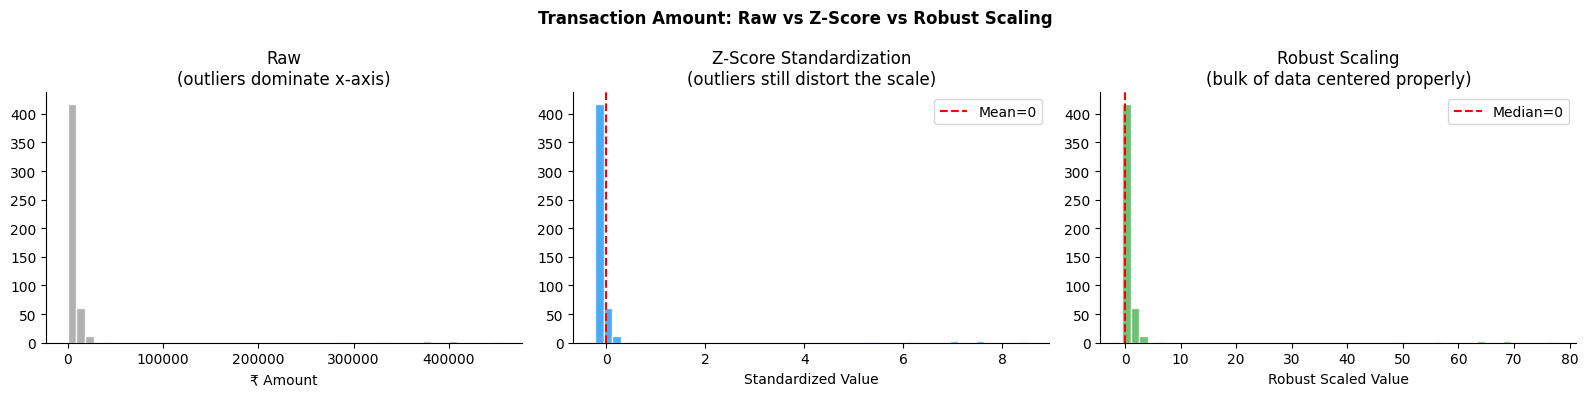


🔍 What you see:
  • Z-Score: the mass of normal transactions appears in a narrow band near 0,
    but the x-axis still stretches far right due to outliers.
  • Robust:  the main cluster is nicely centered, and outliers are just
    large values — still visible but not distorting the center.



In [12]:
# Head-to-head: Z-Score vs Robust on transaction_amount
# This comparison shows WHY Robust scaling exists

scaler_robust = RobustScaler()
tx_zscore = StandardScaler().fit_transform(tx.reshape(-1, 1)).flatten()
tx_robust = scaler_robust.fit_transform(tx.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Transaction Amount: Raw vs Z-Score vs Robust Scaling', fontweight='bold')

# Raw
axes[0].hist(tx, bins=50, color='#9E9E9E', alpha=0.8, edgecolor='white')
axes[0].set_title('Raw\n(outliers dominate x-axis)')
axes[0].set_xlabel('₹ Amount')

# Z-Score
axes[1].hist(tx_zscore, bins=50, color='#2196F3', alpha=0.8, edgecolor='white')
axes[1].set_title('Z-Score Standardization\n(outliers still distort the scale)')
axes[1].set_xlabel('Standardized Value')
axes[1].axvline(0, color='red', linestyle='--', label='Mean=0')
axes[1].legend()

# Robust
axes[2].hist(tx_robust, bins=50, color='#4CAF50', alpha=0.8, edgecolor='white')
axes[2].set_title('Robust Scaling\n(bulk of data centered properly)')
axes[2].set_xlabel('Robust Scaled Value')
axes[2].axvline(0, color='red', linestyle='--', label='Median=0')
axes[2].legend()

plt.tight_layout()
plt.show()

print("""
🔍 What you see:
  • Z-Score: the mass of normal transactions appears in a narrow band near 0,
    but the x-axis still stretches far right due to outliers.
  • Robust:  the main cluster is nicely centered, and outliers are just
    large values — still visible but not distorting the center.
""")

In [13]:
# Apply Robust Scaling to the full dataset with sklearn

scaler_robust_full = RobustScaler()
df_robust = pd.DataFrame(
    scaler_robust_full.fit_transform(df),
    columns=df.columns
)

print("After Robust Scaling — Median ≈ 0, IQR ≈ 1:")
print("\nMedians (should be ≈ 0):")
print(df_robust.median().round(4).to_string())
print("\nIQR (should be ≈ 1):")
print((df_robust.quantile(0.75) - df_robust.quantile(0.25)).round(4).to_string())

After Robust Scaling — Median ≈ 0, IQR ≈ 1:

Medians (should be ≈ 0):
annual_income         0.0
credit_score          0.0
debt_to_income        0.0
transaction_amount    0.0

IQR (should be ≈ 1):
annual_income         1.0
credit_score          1.0
debt_to_income        1.0
transaction_amount    1.0


# OPTIONAL

---
## Section 5 — Side-by-Side Comparison & When to Use What ⏱️

Now let's compare all three scalers on all four features at once, and build a decision framework.

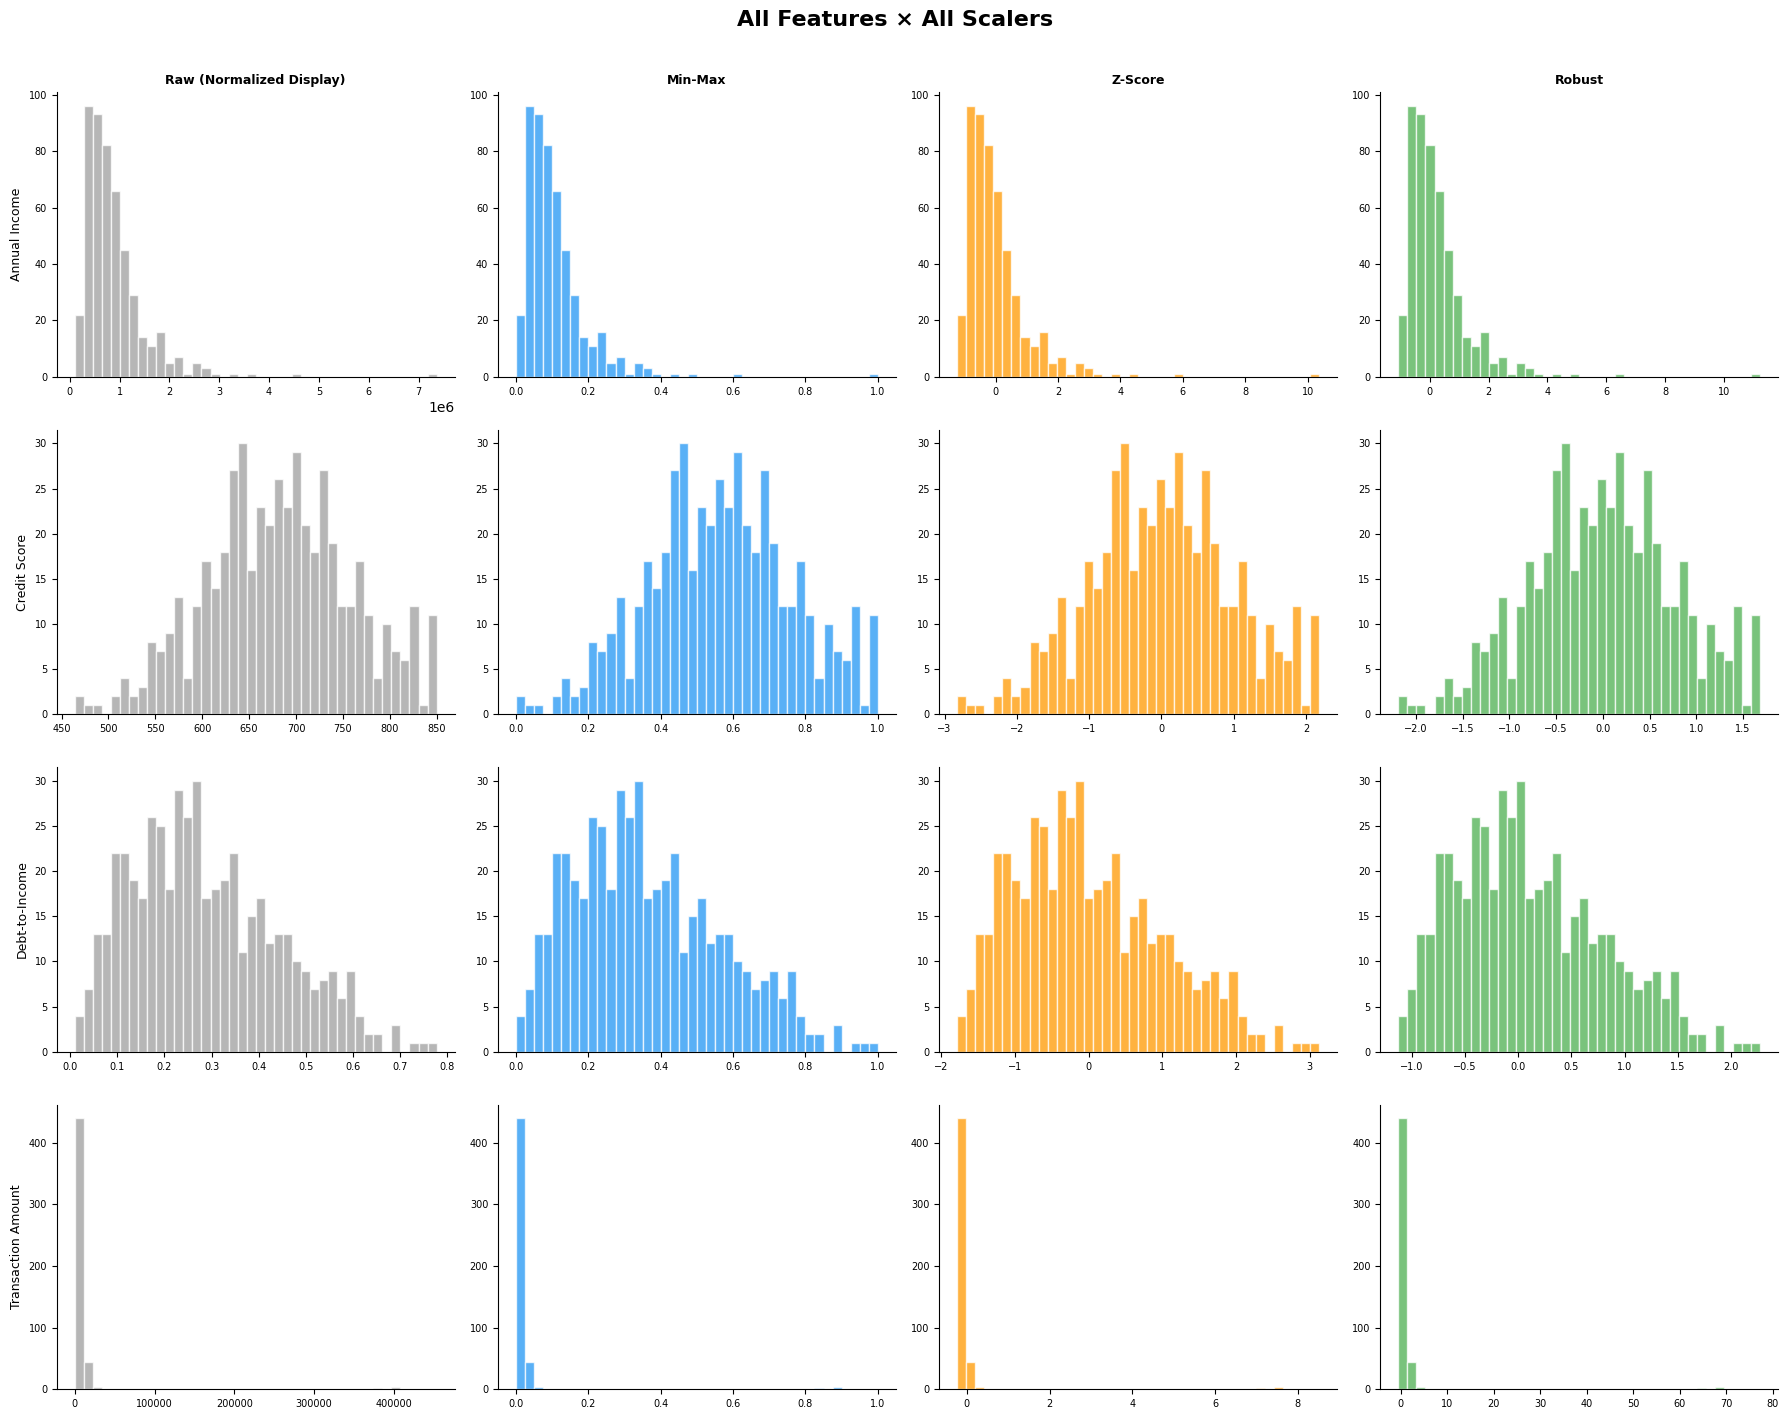

In [14]:
# -------------------------------------------------------
# Full side-by-side comparison of all three scalers
# across all four features
# -------------------------------------------------------

features = ['annual_income', 'credit_score', 'debt_to_income', 'transaction_amount']
feature_labels = ['Annual Income', 'Credit Score', 'Debt-to-Income', 'Transaction Amount']
scaler_names = ['Raw (Normalized Display)', 'Min-Max', 'Z-Score', 'Robust']
scaler_colors = ['#9E9E9E', '#2196F3', '#FF9800', '#4CAF50']

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
fig.suptitle('All Features × All Scalers', fontsize=16, fontweight='bold', y=1.01)

datasets = [
    df,        # raw
    df_minmax,
    df_zscore,
    df_robust
]

for col_idx, (ds, scaler_name, color) in enumerate(zip(datasets, scaler_names, scaler_colors)):
    for row_idx, (feat, feat_label) in enumerate(zip(features, feature_labels)):
        ax = axes[row_idx][col_idx]
        ax.hist(ds[feat], bins=40, color=color, alpha=0.75, edgecolor='white')
        if row_idx == 0:
            ax.set_title(scaler_name, fontweight='bold', fontsize=9)
        if col_idx == 0:
            ax.set_ylabel(feat_label, fontsize=9)
        ax.tick_params(axis='both', labelsize=7)

plt.tight_layout()
plt.show()

In [15]:
# -------------------------------------------------------
# Decision Framework: Which scaler to use?
# -------------------------------------------------------

summary = pd.DataFrame({
    'Scaler': ['Min-Max', 'Z-Score', 'Robust'],
    'Output Range': ['[0, 1]', '≈ (-3, 3)', 'Centered at 0, no fixed range'],
    'Center Used': ['Min', 'Mean', 'Median'],
    'Spread Used': ['Max - Min', 'Std Dev', 'IQR (Q3 - Q1)'],
    'Sensitive to Outliers?': ['🔴 Very', '🟡 Somewhat', '🟢 Minimally'],
    'Best For': [
        'Neural nets, bounded features',
        'Normally distributed features (returns, scores)',
        'Skewed data, outlier-heavy (transactions, income)'
    ]
})

print(summary.to_string(index=False))

 Scaler                  Output Range Center Used   Spread Used Sensitive to Outliers?                                          Best For
Min-Max                        [0, 1]         Min     Max - Min                 🔴 Very                     Neural nets, bounded features
Z-Score                     ≈ (-3, 3)        Mean       Std Dev             🟡 Somewhat   Normally distributed features (returns, scores)
 Robust Centered at 0, no fixed range      Median IQR (Q3 - Q1)            🟢 Minimally Skewed data, outlier-heavy (transactions, income)


In [16]:
# -------------------------------------------------------
# Practical recommendation for our loan dataset
# -------------------------------------------------------

recommendations = {
    'annual_income':      ('Robust', 'Skewed (log-normal), real-world income has extreme values'),
    'credit_score':       ('Z-Score', 'Approximately normal, well-bounded, no extreme outliers'),
    'debt_to_income':     ('Min-Max', 'Already in [0,1], neural nets often used for credit risk'),
    'transaction_amount': ('Robust', 'Heavily skewed with large outliers — perfect Robust use case'),
}

print("📋 Recommended Scaler for Each Feature in Our Dataset:\n")
print(f"{'Feature':<25} {'Recommended Scaler':<22} {'Reason'}")
print("-" * 80)
for feat, (scaler, reason) in recommendations.items():
    print(f"{feat:<25} {scaler:<22} {reason}")

print("""
💡 Key Takeaways:
   1. There is no single 'best' scaler — it depends on your data's distribution.
   2. Always visualize your features BEFORE choosing a scaler.
   3. Always fit scalers on TRAINING data only, then apply to test data.
   4. Different features in the same model can use different scalers.
   5. When in doubt on skewed financial data → start with Robust Scaling.
""")

📋 Recommended Scaler for Each Feature in Our Dataset:

Feature                   Recommended Scaler     Reason
--------------------------------------------------------------------------------
annual_income             Robust                 Skewed (log-normal), real-world income has extreme values
credit_score              Z-Score                Approximately normal, well-bounded, no extreme outliers
debt_to_income            Min-Max                Already in [0,1], neural nets often used for credit risk
transaction_amount        Robust                 Heavily skewed with large outliers — perfect Robust use case

💡 Key Takeaways:
   1. There is no single 'best' scaler — it depends on your data's distribution.
   2. Always visualize your features BEFORE choosing a scaler.
   3. Always fit scalers on TRAINING data only, then apply to test data.
   4. Different features in the same model can use different scalers.
   5. When in doubt on skewed financial data → start with Robust Scaling.



In [17]:
# -------------------------------------------------------
# ⭐ PRODUCTION PATTERN: The Right Way to Scale
# ---
# The #1 mistake beginners make: fitting the scaler on ALL data.
# This "leaks" test data statistics into training — your model
# will look better than it really is. Always fit on train only.
# -------------------------------------------------------

from sklearn.model_selection import train_test_split

# Split first
X = df.values
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# Fit scaler ONLY on training data
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled  = scaler.transform(X_test)         # transform ONLY (no fit!)

print("✅ Correct Production Pattern:")
print(f"   Training set: {X_train.shape[0]} samples → fit and transform")
print(f"   Test set:     {X_test.shape[0]} samples  → transform only (using train's median/IQR)")
print()
print("❌ Never do this:")
print("   scaler.fit_transform(X_all)   ← data leakage!")
print("   scaler.fit(X_test)            ← data leakage!")

✅ Correct Production Pattern:
   Training set: 400 samples → fit and transform
   Test set:     100 samples  → transform only (using train's median/IQR)

❌ Never do this:
   scaler.fit_transform(X_all)   ← data leakage!
   scaler.fit(X_test)            ← data leakage!


---
## 🎓 Summary & Next Steps

### What You Learned

| Scaler | Formula | Key Strength | Key Weakness |
|---|---|---|---|
| **Min-Max** | $(X - X_{min}) / (X_{max} - X_{min})$ | Bounded output [0,1] | Outlier-sensitive |
| **Z-Score** | $(X - \mu) / \sigma$ | Great for normal distributions | Mean/std shift with outliers |
| **Robust** | $(X - median) / IQR$ | Outlier-resistant | Output is unbounded |

### The Golden Rules

1. **Always visualize your data first** before choosing a scaler
2. **Fit on training data only** — never on test data (avoids data leakage)
3. **Match the scaler to the distribution** — not just habit
4. **For skewed financial features** (income, volume, transactions) → use Robust
5. **For normally distributed features** (returns, credit scores) → Z-Score works well

### What to Explore Next - EXERCISE 

- **Log transformation** — Apply `np.log1p()` to skewed features *before* scaling
- **QuantileTransformer** — sklearn tool that maps any distribution to normal or uniform
- **PowerTransformer (Box-Cox / Yeo-Johnson)** — automatic skewness correction
- **Feature pipelines** — `sklearn.pipeline.Pipeline` to chain transformations cleanly

